In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

import lightgbm as lgb
from sklearn.model_selection import KFold, train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.metrics import mean_squared_error
import optuna

warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

%matplotlib inline

In [2]:
train = pd.read_csv('/kaggle/input/playground-series-s5e9/train.csv',index_col='id')
test = pd.read_csv('/kaggle/input/playground-series-s5e9/test.csv',index_col='id')

In [3]:
train.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
id,,,,,,,,,,
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 524164 entries, 0 to 524163
Data columns (total 10 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   RhythmScore                524164 non-null  float64
 1   AudioLoudness              524164 non-null  float64
 2   VocalContent               524164 non-null  float64
 3   AcousticQuality            524164 non-null  float64
 4   InstrumentalScore          524164 non-null  float64
 5   LivePerformanceLikelihood  524164 non-null  float64
 6   MoodScore                  524164 non-null  float64
 7   TrackDurationMs            524164 non-null  float64
 8   Energy                     524164 non-null  float64
 9   BeatsPerMinute             524164 non-null  float64
dtypes: float64(10)
memory usage: 44.0 MB


In [5]:
train.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


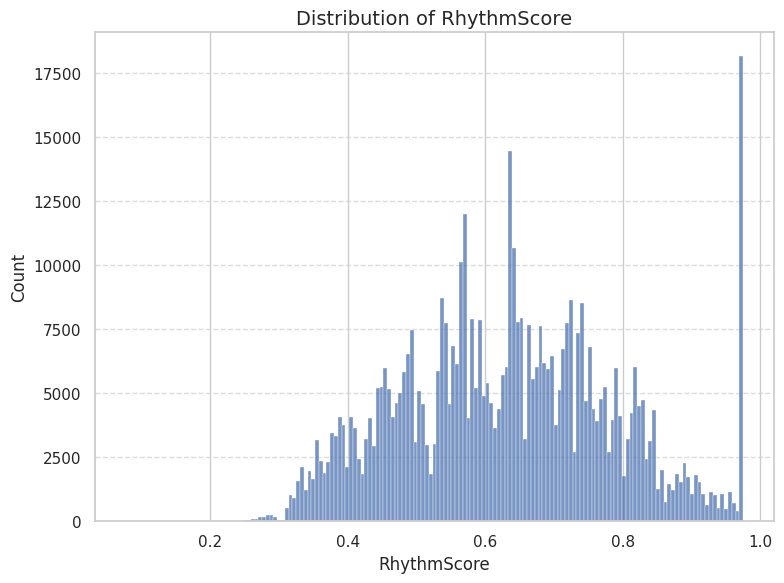

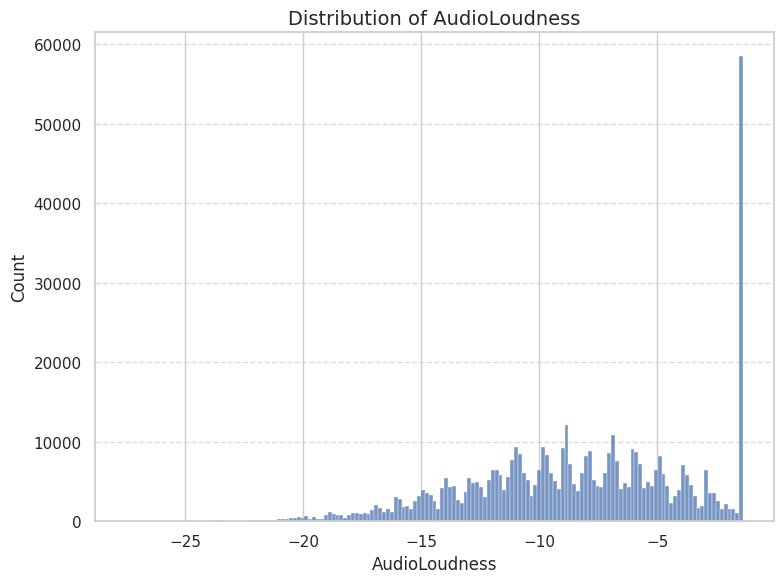

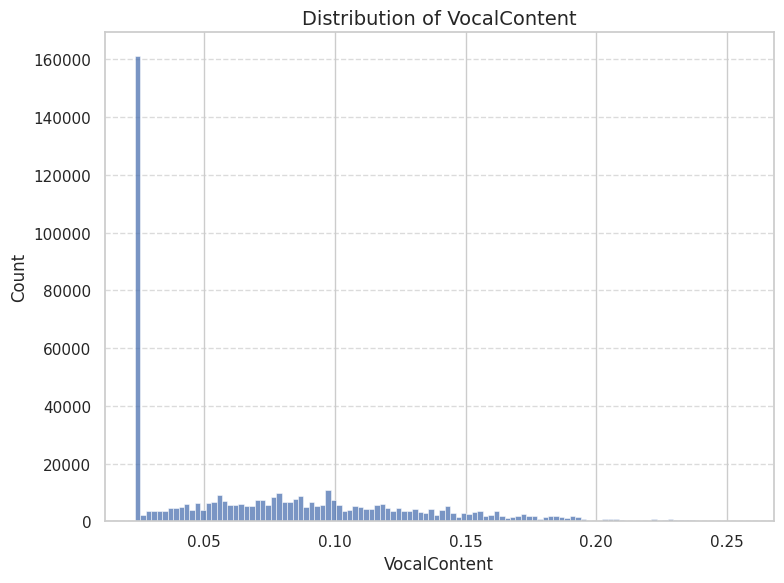

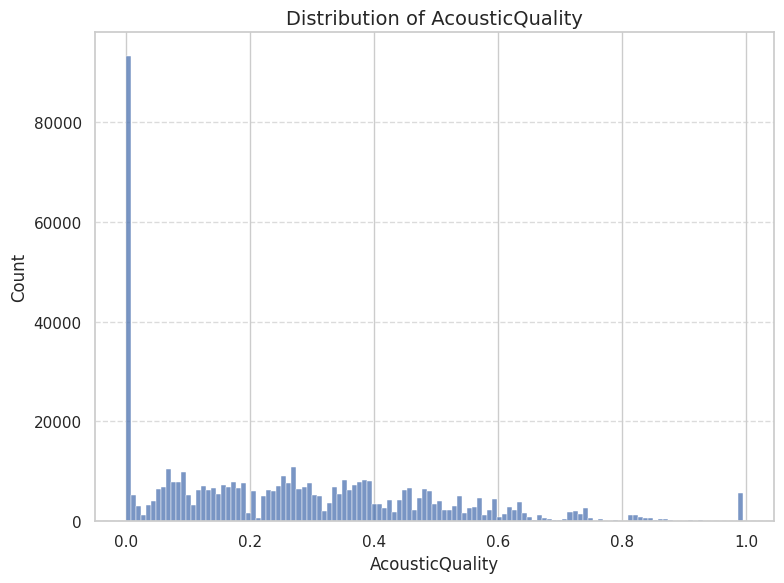

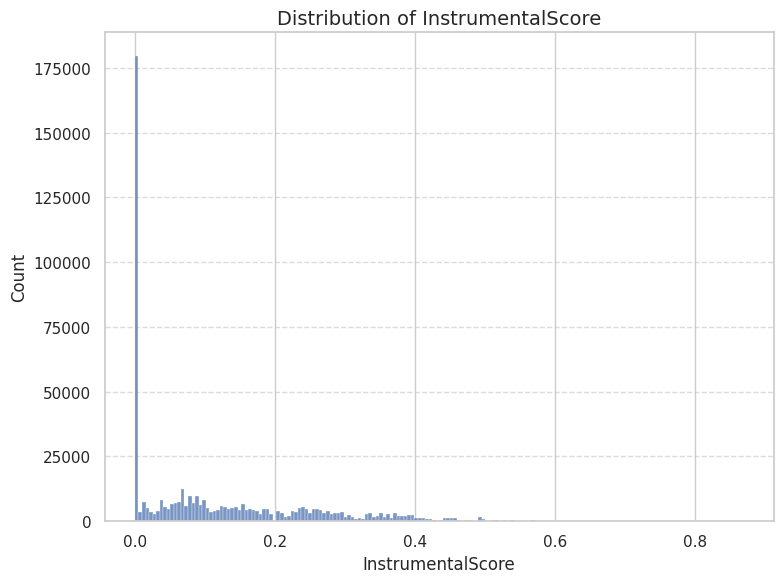

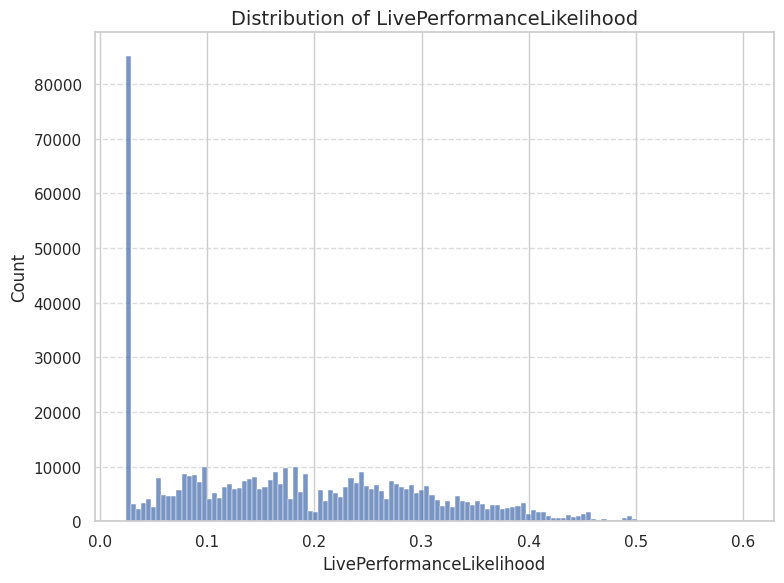

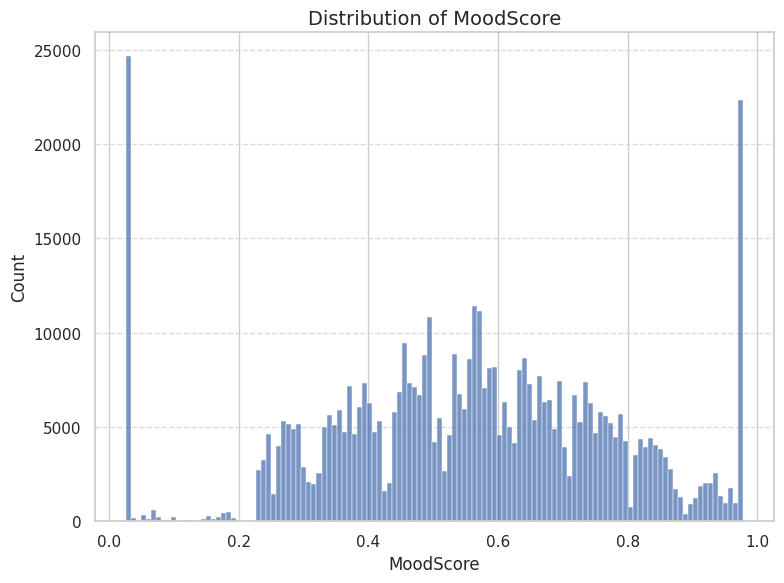

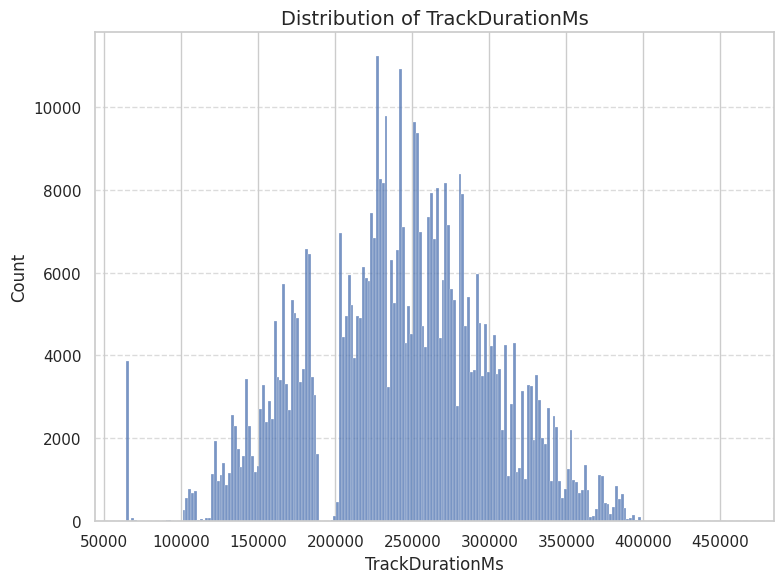

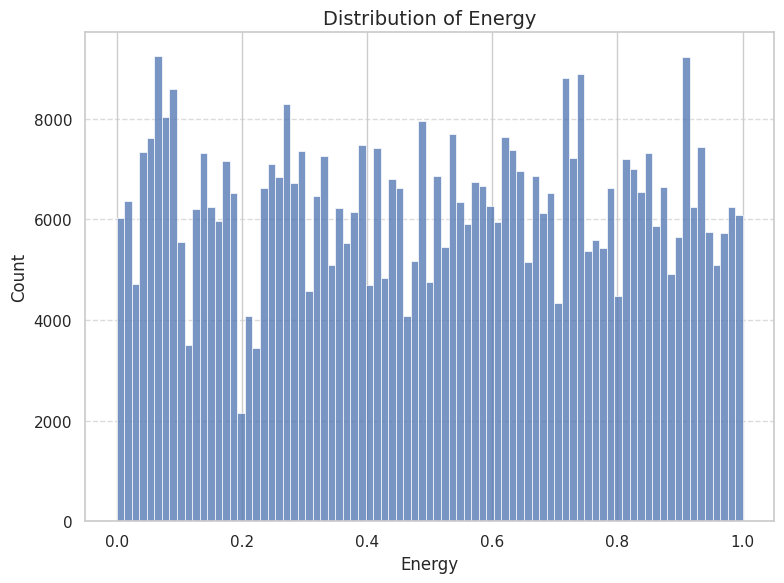

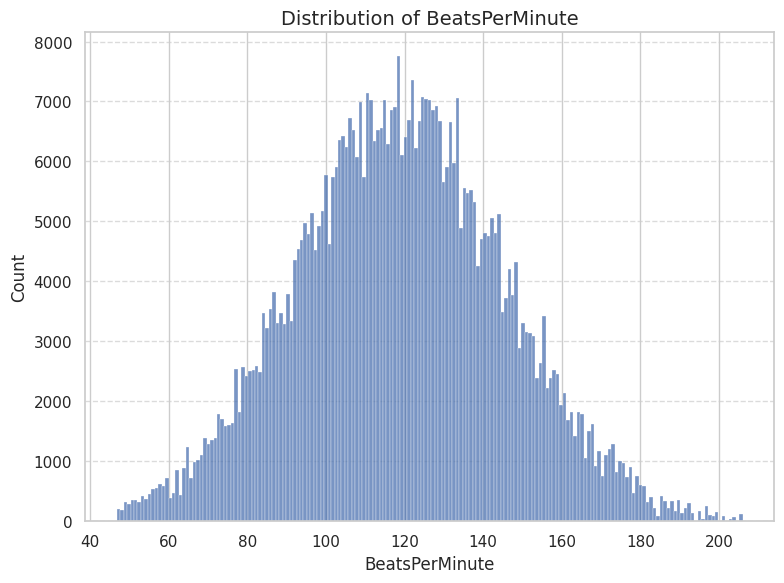

In [6]:
for col in train.columns:
    plt.figure(figsize=(8,6))
    sns.histplot(data=train,x=col)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

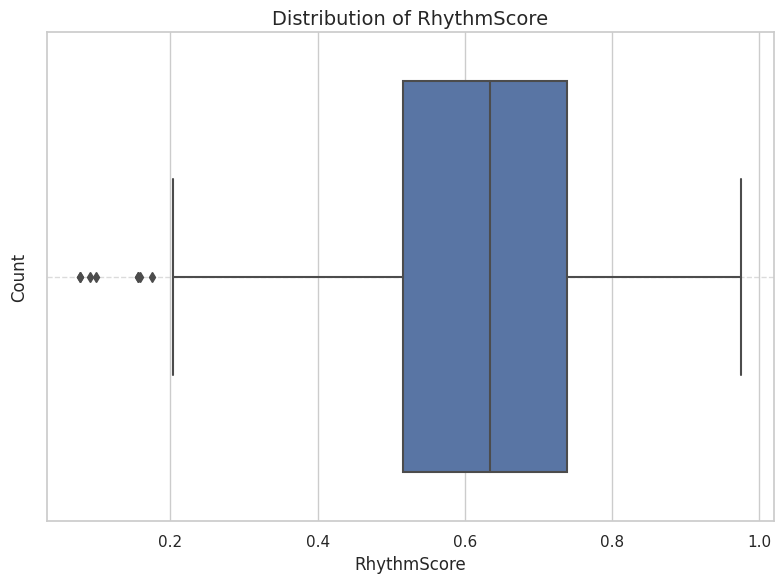

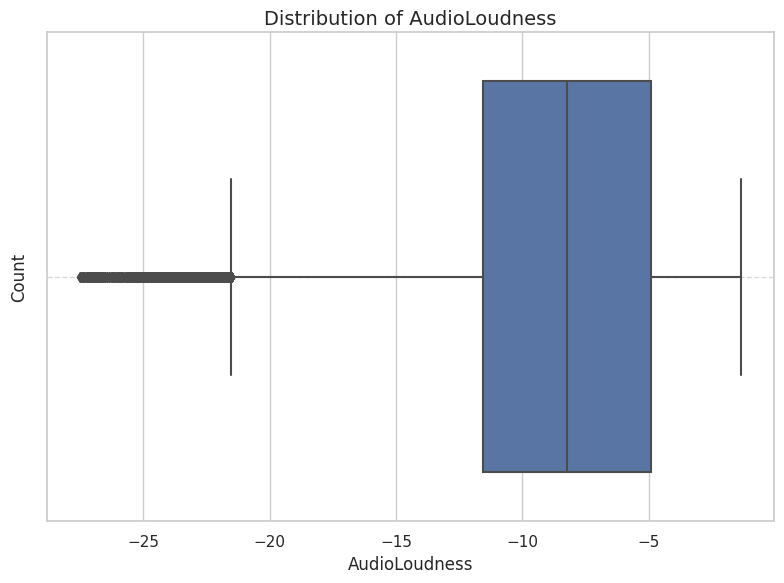

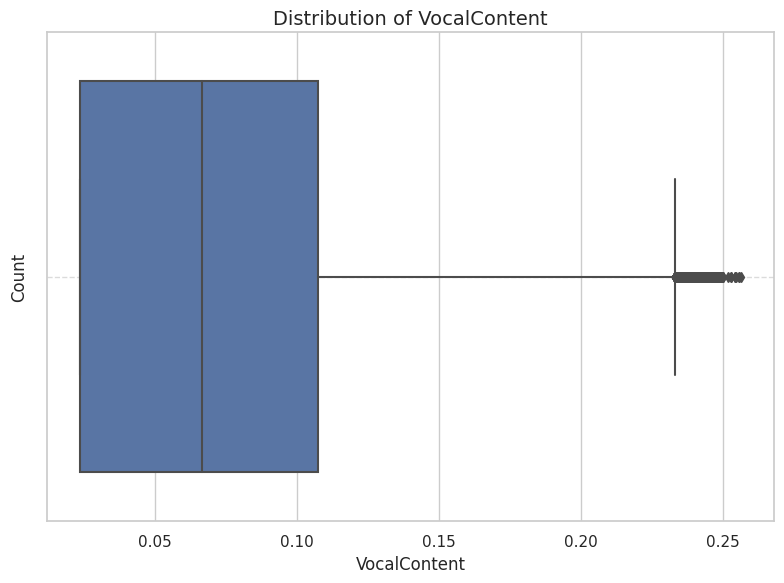

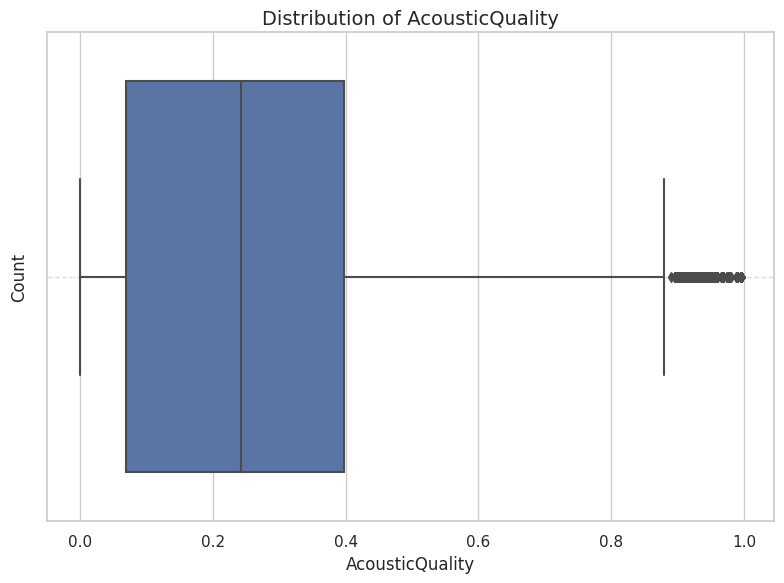

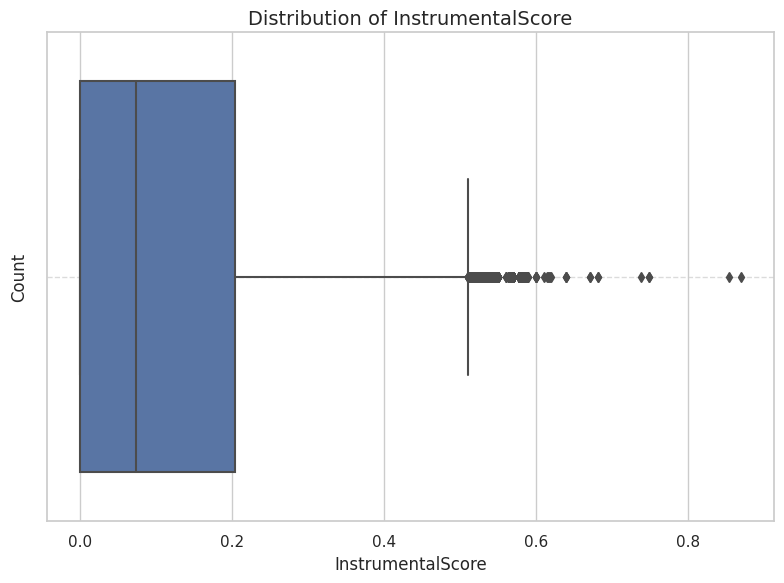

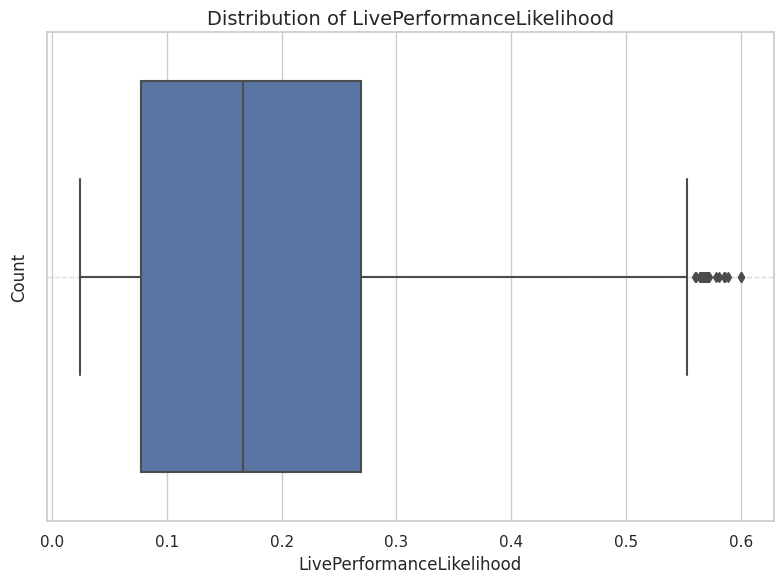

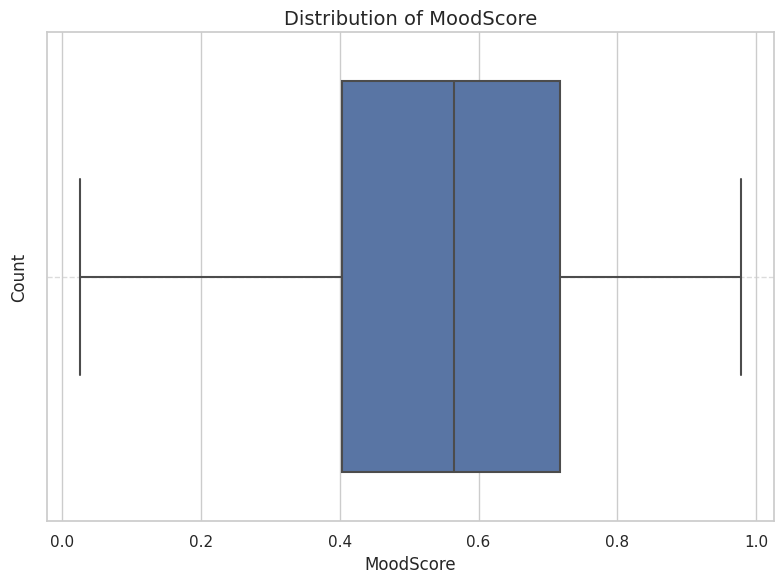

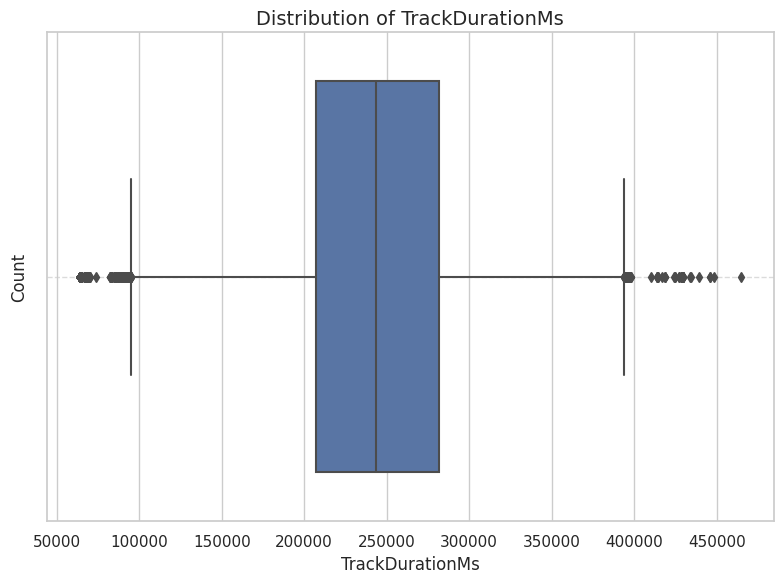

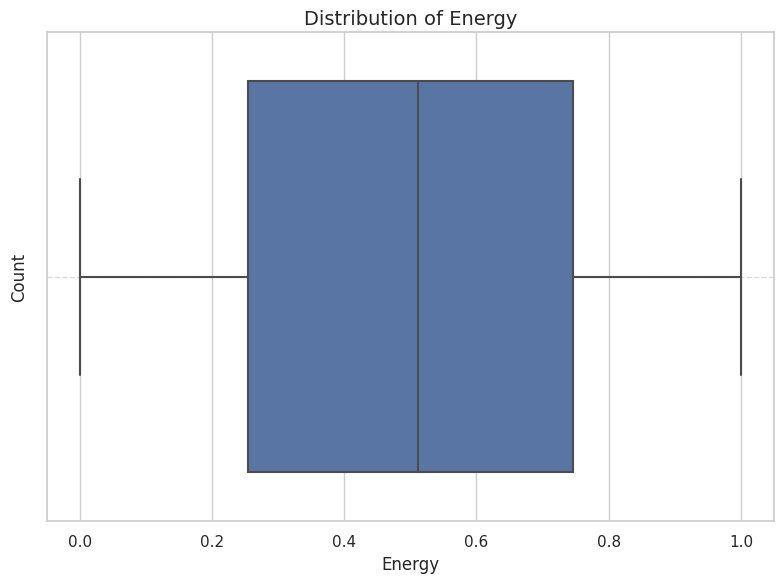

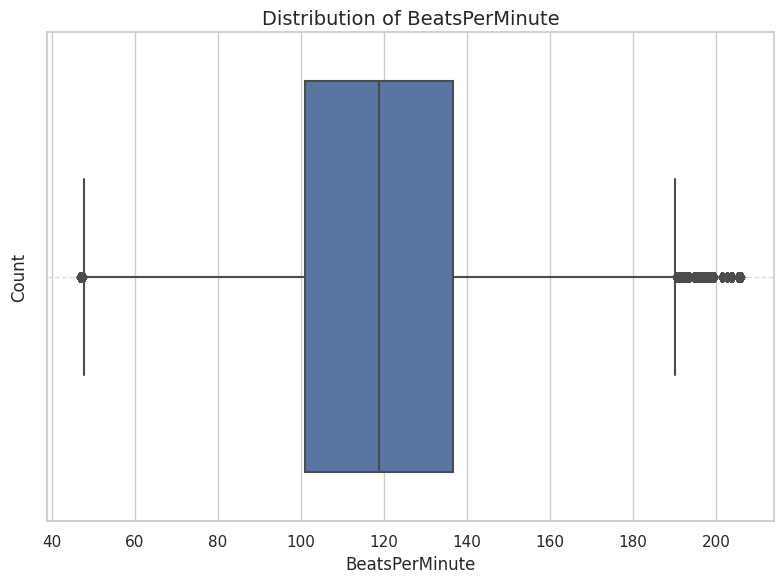

In [7]:
for col in train.columns:
    plt.figure(figsize=(8,6))
    sns.boxplot(data=train,x=col)
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

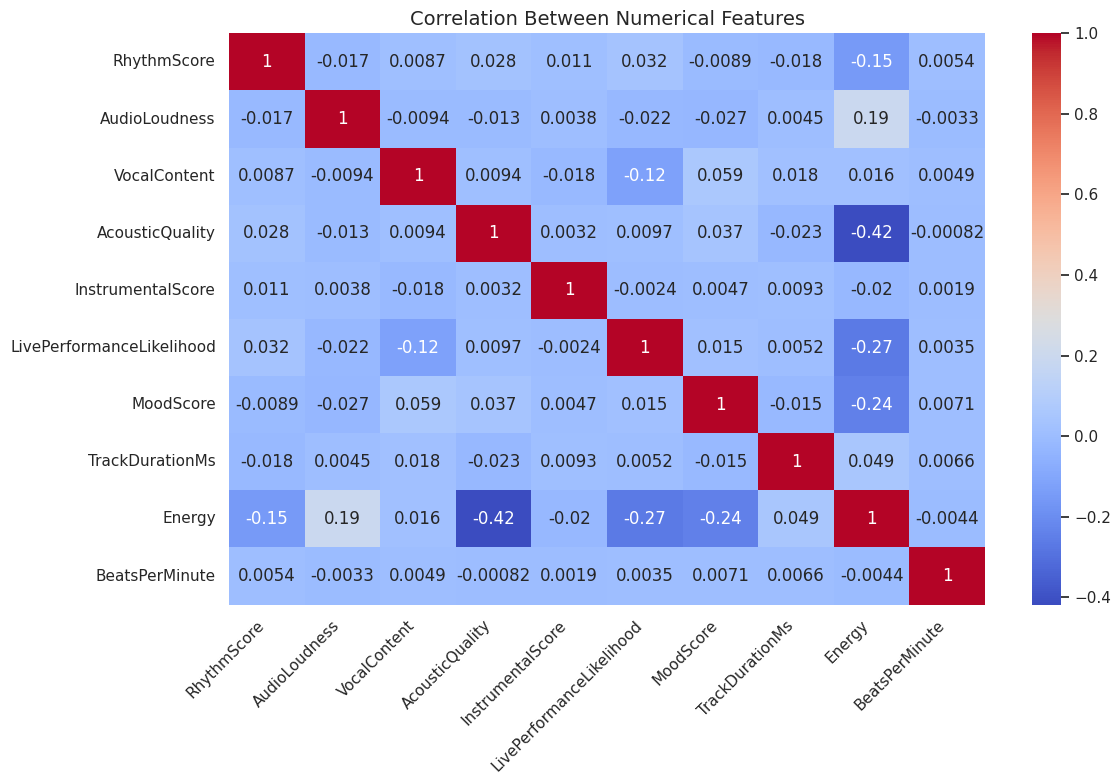

In [8]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    train.corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Between Numerical Features", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [9]:
X = train.drop('BeatsPerMinute', axis=1).copy()
y = train['BeatsPerMinute']
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, shuffle=True, random_state=17)

In [10]:
model = lgb.LGBMRegressor(objective = 'regression',random_state=42,verbose=-1)

In [11]:
model.fit(X_train,y_train)

LGBMRegressor(objective='regression', random_state=42, verbose=-1)

In [12]:
y_pred = model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = model.score(X_train,y_train)
print(f"Root Mean Squared Error: {rmse}")
print(f"R^2: {r2}")

Root Mean Squared Error: 26.509394933472123
R^2: 0.010665636042880622


In [13]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 500, 1000),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "num_leaves": trial.suggest_int("num_leaves", 15, 50),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
        "random_state": 42,
        "device": "gpu",           
        "gpu_platform_id": 0,      
        "gpu_device_id": 0         
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmse_scores = []

    for train_idx, valid_idx in kf.split(X, y):
        X_train, X_valid = X.iloc[train_idx], X.iloc[valid_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[valid_idx]

        model = lgb.LGBMRegressor(**params)
        
        model.fit(
            X_train, y_train,
            eval_set=[(X_valid, y_valid)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(5, verbose=False)],
        )
        
        preds = model.predict(X_valid, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_valid, preds, squared=False)
        rmse_scores.append(rmse)
    
    return np.mean(rmse_scores)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)

print("Best trial:")
print("  Value (mean RMSE):", study.best_trial.value)
print("  Params:", study.best_trial.params)



[I 2025-09-02 01:39:45,781] A new study created in memory with name: no-name-cf7401f5-7ac5-4bf7-b01b-656f841bbf5c
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
[I 2025-09-02 01:39:55,782] Trial 0 finished with value: 26.460268519471732 and parameters: {'n_estimators': 987, 'learning_rate': 0.06280324652634281, 'max_depth': 5, 'num_leaves': 32, 'subsam

Best trial:
  Value (mean RMSE): 26.45797480620568
  Params: {'n_estimators': 731, 'learning_rate': 0.09011600457191057, 'max_depth': 7, 'num_leaves': 15, 'subsample': 0.7970883750940299, 'colsample_bytree': 0.8434993142790836, 'reg_alpha': 6.2931122482346975, 'reg_lambda': 6.340707385864816e-08}


In [14]:
best_params = study.best_trial.params
best_params.update({
    "device": "gpu",
    "gpu_platform_id": 0,
    "gpu_device_id": 0,
    "random_state": 42
})

best_lgb = lgb.LGBMRegressor(**best_params)
best_lgb.fit(X_train,y_train)

LGBMRegressor(colsample_bytree=0.8434993142790836, device='gpu',
              gpu_device_id=0, gpu_platform_id=0,
              learning_rate=0.09011600457191057, max_depth=7, n_estimators=731,
              num_leaves=15, random_state=42, reg_alpha=6.2931122482346975,
              reg_lambda=6.340707385864816e-08, subsample=0.7970883750940299)

In [15]:
y_pred = best_lgb.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = best_lgb.score(X_train,y_train)
print(f"Root Mean Squared Error: {rmse}")
print(f"R^2: {r2}")

Root Mean Squared Error: 26.52648850565609
R^2: 0.02597739341283245


In [16]:
submission = pd.read_csv("/kaggle/input/playground-series-s5e9/sample_submission.csv")
submission['BeatsPerMinute'] = best_lgb.predict(test)
submission.to_csv("submission.csv", index=False)